# End-to-End ML-EDA für zeitintervallbasierte Produktionsdaten (V3)
**Fokus:** Datenvorbereitung für ein sequentielles LSTM-Modell unter Verwendung von `DatumNEU` und Aggregation paralleler Zeitfenster.

### Core-Anpassungen in dieser Version:
1. **Fokus auf `DatumNEU`:** Das unbereinigte originale `Datum` wird ignoriert. Die Qualitäts- und Zeitanalyse baut strikt auf `DatumNEU` auf.
2. **Ausschluss von Textrauschen:** Unstrukturierte Freitexte (`Bemerkung`, `Bemerkung_norm`) werden konsequent aus den Statistiken entfernt.
3. **Target Sanity Check:** Das Target `Störfall` wird über logische Indikatoren (z.B. Ausfalldauern) redefinisiert, um Buchungsfehler im ERP zu korrigieren, bevor aggregiert wird.
4. **Intervall-Deduplikation:** Mehrere Zeilen innerhalb desselben Fensters werden zu einem Zeitschritt komprimiert.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

FILE_PATH = r"C:\Users\golde\PycharmProjects\pred_main_project_brueggen\data\lstm ready data\stoerliste_mit_auftragsdaten_2024_2026.csv"
DELIMITER = ";"
TARGET_COL = "Störfall"

print(f"Lese Rohdaten ein von: {FILE_PATH}")
df_raw = pd.read_csv(FILE_PATH, sep=DELIMITER, low_memory=False)

## 1. Statistische Übersicht der aggregierten Features
Um die Verteilung unserer Prädiktoren im Detail zu verstehen, betrachten wir verschiedene statistische Maßzahlen:
* **Lageparameter:** Mean (Mittelwert) vs. Median (50%-Quantil). Starke Abweichungen deuten auf Ausreißer hin.
* **Streuung:** Standardabweichung (std) und Interquartilsabstand (IQR).
* **Form der Verteilung:** * **Schiefe (Skewness):** Werte > 1 oder < -1 deuten auf starke Asymmetrie hin (oft ein Fall für Log-Transformationen).
  * **Wölbung (Kurtosis):** Hohe Werte bedeuten starke Ausreißer in den Rändern (Heavy Tails).
* **Kategorial:** Kardinalität (Anzahl einzigartiger Werte) und Modus (häufigster Wert).

In [6]:
# --- VORBEREITUNG: 'Datum' sowie Freitexte ('Bemerkung', 'Bemerkung_norm') ausschließen ---
cols_to_exclude = ['Datum', 'Bemerkung', 'Bemerkung_norm']
df_stats = df.drop(columns=cols_to_exclude, errors='ignore')

# SICHERHEITSNETZ 1: Falls der Code NACH der Aggregation läuft, 
# rekonstruieren wir 'DatumNEU' blitzschnell aus dem Zeitstempel
if 'DatumNEU' not in df_stats.columns:
    if 'Timestamp_Start' in df_stats.columns:
        df_stats['DatumNEU'] = pd.to_datetime(df_stats['Timestamp_Start']).dt.strftime('%Y-%m-%d')
    elif 'Timestamp_End' in df_stats.columns:
        df_stats['DatumNEU'] = pd.to_datetime(df_stats['Timestamp_End']).dt.strftime('%Y-%m-%d')

# Listen bereinigen (nur Spalten behalten, die existieren und nicht ausgeschlossen wurden)
num_features = [c for c in num_features if c in df_stats.columns and c not in cols_to_exclude]
cat_features = [c for c in cat_features if c in df_stats.columns and c not in cols_to_exclude]

# Sicherstellen, dass DatumNEU definitiv in den kategorialen Features landet
if 'DatumNEU' in df_stats.columns and 'DatumNEU' not in cat_features:
    cat_features.append('DatumNEU')


print("--- 1. STATISTIKEN NUMERISCHER FEATURES ---")
if len(num_features) > 0:
    num_stats = df_stats[num_features].describe().T
    num_stats['skewness'] = df_stats[num_features].skew()   
    num_stats['kurtosis'] = df_stats[num_features].kurtosis() 
    num_stats['IQR'] = num_stats['75%'] - num_stats['25%'] 
    
    num_stats = num_stats[['count', 'mean', '50%', 'std', 'min', 'max', 'IQR', 'skewness', 'kurtosis']]
    num_stats = num_stats.rename(columns={'50%': 'median'})
    display(num_stats.round(3))
    
    highly_skewed = num_stats[abs(num_stats['skewness']) > 1.5].index.tolist()
    if highly_skewed:
        print(f"\n🚨 ML-Hinweis: Folgende Features sind stark verzerrt (Schiefe > 1.5 oder < -1.5):")
        print(f"   {highly_skewed}")
        print("   -> Empfehlung für Pipeline: Vor dem StandardScaler eine Log- oder Power-Transformation (Yeo-Johnson) testen!")
else:
    print("Keine numerischen Features vorhanden.")


print("\n--- 2. STATISTIKEN KATEGORIALER FEATURES ---")
if len(cat_features) > 0:
    # .astype(object) zwingt Pandas dazu, auch Datetime-Spalten 
    # wie 'DatumNEU' sauber mit 'count', 'unique' und 'top' in der Tabelle zu beschreiben!
    cat_stats = df_stats[cat_features].astype(object).describe().T
    
    # Fehlende Werte in Prozent ergänzen
    cat_stats['missing_%'] = (df_stats[cat_features].isnull().sum() / len(df_stats) * 100).values
    
    display(cat_stats.round(2))
    
    # Warnsystem für hohe Kardinalität
    # 'DatumNEU' wird hier ignoriert, da ein Datum logischerweise viele einzigartige Werte besitzt
    high_cardinality = cat_stats[(cat_stats['unique'] > 15) & (cat_stats.index != 'DatumNEU')].index.tolist()
    if high_cardinality:
        print(f"\n🚨 ML-Hinweis: Hohe Kardinalität in kategorialen Variablen gefunden (>15 einzigartige Werte):")
        print(f"   {high_cardinality}")
        print("   -> Empfehlung: Hier kein One-Hot-Encoding verwenden (bläht die Feature-Matrix extrem auf).")
        print("      Besser: Target Encoding, Frequenz-Encoding oder eine Embedding-Layer vorschalten.")
else:
    print("Keine kategorialen Features vorhanden.")

--- 1. STATISTIKEN NUMERISCHER FEATURES ---


,count,mean,median,std,min,max,IQR,skewness,kurtosis
Wochentag,8980.0,2.772,3.000,1.330,1.000,5.000,2.000,0.163,-1.148
Jahr,8980.0,2024.790,2025.000,0.721,2024.000,2026.000,1.000,0.338,-1.035
Monat,8980.0,5.867,5.000,3.469,1.000,12.000,6.000,0.262,-1.262
Tag,8980.0,15.586,15.000,8.401,1.000,31.000,14.000,0.049,-1.141
Quartal,8980.0,2.297,2.000,1.137,1.000,4.000,2.000,0.270,-1.341
Dauer Arbeits-zeit,8980.0,55.577,60.000,13.285,15.000,75.000,15.000,-1.143,1.144
Anzahl MA,8980.0,4.194,4.000,1.056,0.000,9.000,1.000,-1.100,3.783
Anzahl/ Std.,8980.0,0.082,0.000,0.463,0.000,6.000,0.000,6.483,47.310
Sollzeit/ Stück (Min),6077.0,1.548,0.000,3.281,0.000,8.500,0.000,1.647,0.714
Zeit_von_min,8980.0,767.938,780.000,300.841,0.000,1380.000,570.000,0.007,-1.154



🚨 ML-Hinweis: Folgende Features sind stark verzerrt (Schiefe > 1.5 oder < -1.5):
   ['Anzahl/ Std.', 'Sollzeit/ Stück (Min)', 'Zeit_seit_letztem_Fehler_min']
   -> Empfehlung für Pipeline: Vor dem StandardScaler eine Log- oder Power-Transformation (Yeo-Johnson) testen!

--- 2. STATISTIKEN KATEGORIALER FEATURES ---


,count,unique,top,freq,missing_%
KW,8980,111,2025/46,121,0.00
Schicht,8980,4,s,4494,0.00
Station/ OP,1889,37,R 06,425,78.96
Bemerkung_std,4909,1399,wartungsplan,798,45.33
Wochenende,8980,1,N,8980,0.00
DatumNEU,8980,473,2026-01-13,34,0.00



🚨 ML-Hinweis: Hohe Kardinalität in kategorialen Variablen gefunden (>15 einzigartige Werte):
   ['KW', 'Station/ OP', 'Bemerkung_std']
   -> Empfehlung: Hier kein One-Hot-Encoding verwenden (bläht die Feature-Matrix extrem auf).
      Besser: Target Encoding, Frequenz-Encoding oder eine Embedding-Layer vorschalten.


## 2. Target Deep-Dive & Logik-Bereinigung (Vor Aggregation)
In Produktionsdaten kommt es oft vor, dass bei einer Schicht zwar Störzeiten eingetragen sind, das finale Target-Flag aber nicht sauber gepflegt wurde. Wir validieren das Target gegen harte Indikatoren (z.B. Ausfalldauern) und überführen es in ein standardisiertes, binäres Format (0 oder 1).

Zielvariable gefunden: Störfall (Typ: object)
Erkannte ML-Aufgabe: **Binäre Klassifikation**
Störfall
J    54.732739
N    45.267261
Name: proportion, dtype: float64


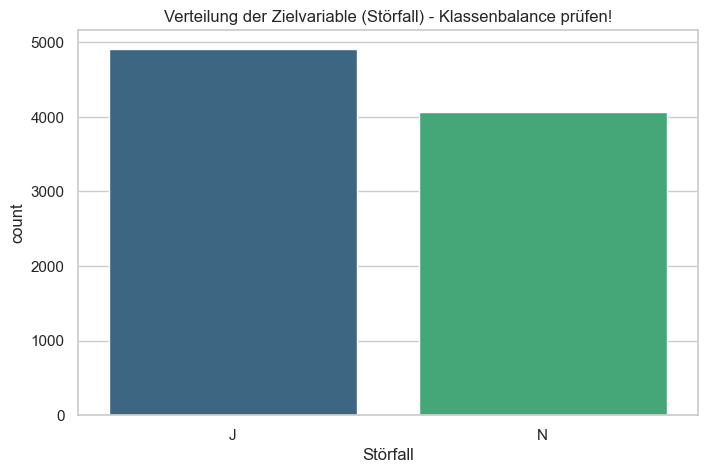

NameError: name 'datetime_cols' is not defined

In [7]:
if TARGET_COL is None or TARGET_COL not in df.columns:
    # Heuristik: Suche nach typischen Namen
    target_candidates = ['target', 'label', 'y', 'class', 'status', 'störfall']
    for col in df.columns:
        if col.lower() in target_candidates:
            TARGET_COL = col
            break

if TARGET_COL in df.columns:
    print(f"Zielvariable gefunden: {TARGET_COL} (Typ: {df[TARGET_COL].dtype})")
    
    # ML-Aufgabe erkennen
    unique_vals = df[TARGET_COL].nunique()
    if pd.api.types.is_numeric_dtype(df[TARGET_COL]) and unique_vals > 20:
        ml_task = "Regression"
    elif unique_vals == 2:
        ml_task = "Binäre Klassifikation"
    else:
        ml_task = "Multiclass Klassifikation"
        
    print(f"Erkannte ML-Aufgabe: **{ml_task}**")
    
    # Visualisierung der Zielvariable
    plt.figure(figsize=(8, 5))
    if "Klassifikation" in ml_task:
        sns.countplot(data=df, x=TARGET_COL, palette='viridis')
        plt.title(f"Verteilung der Zielvariable ({TARGET_COL}) - Klassenbalance prüfen!")
        # Prozentuale Verteilung
        print(df[TARGET_COL].value_counts(normalize=True) * 100)
    else:
        sns.histplot(df[TARGET_COL], kde=True, bins=50, color='blue')
        plt.title(f"Verteilung der Zielvariable ({TARGET_COL})")
    plt.show()
    
    # Zeitliche Struktur des Targets prüfen (falls Zeitvariable vorhanden)
    if len(datetime_cols) > 0:
        time_col = datetime_cols[0]
        print(f"Prüfe zeitliche Entwicklung des Targets entlang: {time_col}")
        # Plot folgt in Sektion 4/5
else:
    print("Keine Zielvariable definiert oder gefunden. Führe unüberwachtes EDA durch.")
    ml_task = "Unsupervised / Unbekannt"

## 3. Datenqualität
Gute Modelle erfordern saubere Daten. Wir analysieren:
* **Missing Values:** Wichtig für die Imputationsstrategie.
* **Duplikate:** Können zu Überanpassung (Overfitting) führen, wenn sie in Train/Test landen.

Spalten mit fehlenden Werten (Altes 'Datum' erfolgreich ignoriert):


,Missing_Count,Percent
Fehlercode,8979,99.988864
Station/ OP_2,8955,99.721604
Station/ OP,7091,78.964365
Station/ OP_1,7091,78.964365
Station/ OP_raw,7091,78.964365
Materialnummer,5926,65.991091
Kundenauftragsnummer,5926,65.991091
Bemerkung_std,4071,45.334076
Sollzeit/ Stück (Min),2903,32.327394


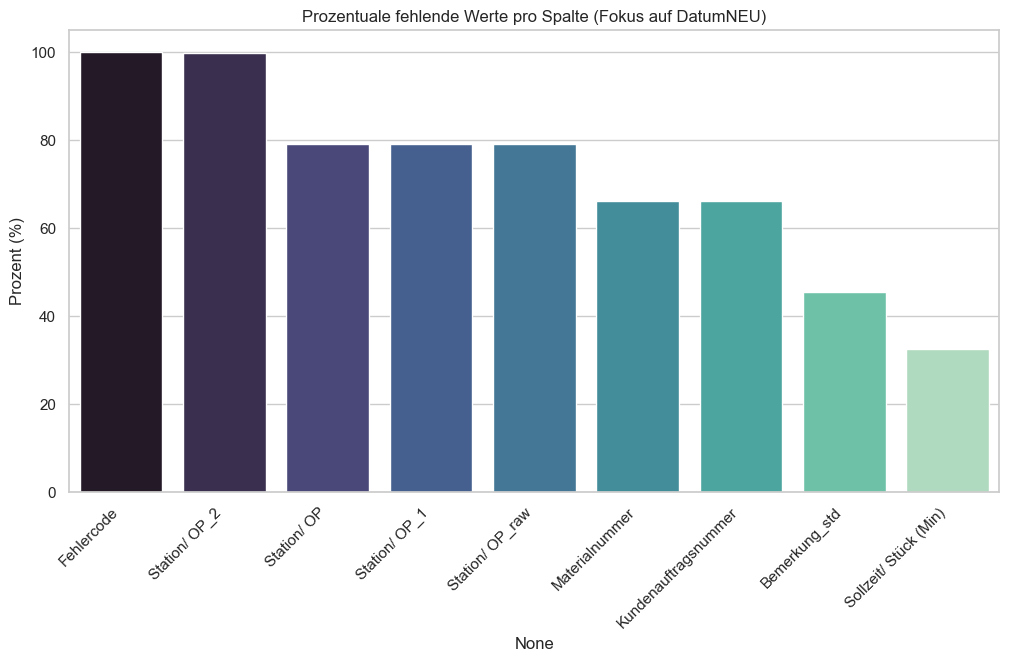

Anzahl exakter Duplikate im Datensatz (vollständig identische Zeilen): 0 (0.00%)
Anzahl Zeilen mit identischem Zeitfenster (DatumNEU, Zeit von, Zeit bis): 1179 (13.13%)
⚠️ ML-Hinweis: 1179 Zeilen sind zeitliche Überlappungen (z.B. mehrere Aufträge pro Schicht).
   Diese MÜSSEN vor dem LSTM-Training aggregiert werden, um die Zeitreihe nicht zu verfälschen!


In [9]:
# --- 1. MISSING VALUES (Fokus auf DatumNEU) ---
# Wir ignorieren die alte 'Datum'-Spalte vollständig, damit nur 'DatumNEU' analysiert wird
df_quality = df.drop(columns=['Datum','Bemerkung','Bemerkung_norm'], errors='ignore')

missing_stats = df_quality.isnull().sum()
missing_stats = missing_stats[missing_stats > 0].sort_values(ascending=False)
missing_percent = (missing_stats / len(df_quality)) * 100

missing_df = pd.DataFrame({'Missing_Count': missing_stats, 'Percent': missing_percent})

if not missing_df.empty:
    print("Spalten mit fehlenden Werten (Altes 'Datum' erfolgreich ignoriert):")
    display(missing_df)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_df.index, y=missing_df['Percent'], palette='mako')
    plt.xticks(rotation=45, ha='right')
    plt.title("Prozentuale fehlende Werte pro Spalte (Fokus auf DatumNEU)")
    plt.ylabel("Prozent (%)")
    plt.show()
else:
    print("Keine fehlenden Werte in den relevanten Spalten (inkl. DatumNEU) gefunden.")


# --- 2. DUPLIKATE (Kontext-Erweiterung) ---
# A) Exakte Duplikate über alle Spalten hinweg
dups_exact = df.duplicated().sum()
print(f"Anzahl exakter Duplikate im Datensatz (vollständig identische Zeilen): {dups_exact} ({dups_exact/len(df)*100:.2f}%)")

# B) Zeitfenster-Duplikate (Mehrere Zeilen/Aufträge zum selben Zeitpunkt)
time_key_cols = ['DatumNEU', 'Zeit von', 'Zeit bis']
if all(col in df.columns for col in time_key_cols):
    dups_time = df.duplicated(subset=time_key_cols).sum()
    print(f"Anzahl Zeilen mit identischem Zeitfenster ({', '.join(time_key_cols)}): {dups_time} ({dups_time/len(df)*100:.2f}%)")
    if dups_time > 0:
        print(f"⚠️ ML-Hinweis: {dups_time} Zeilen sind zeitliche Überlappungen (z.B. mehrere Aufträge pro Schicht).")
        print("   Diese MÜSSEN vor dem LSTM-Training aggregiert werden, um die Zeitreihe nicht zu verfälschen!")

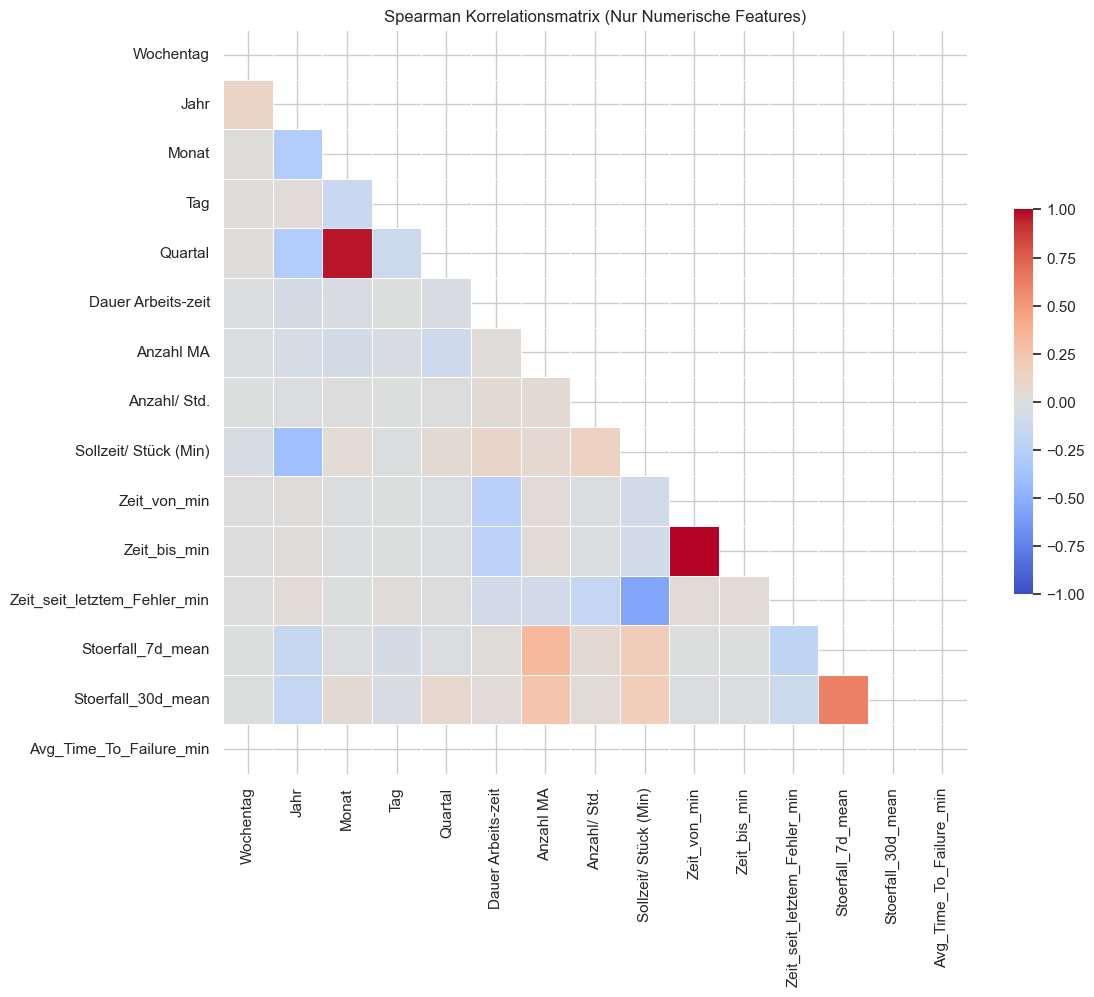

🚨 Warnung: Folgende Feature-Paare sind stark korreliert (>0.85). Eines davon sollte ggf. entfernt werden:
- Monat und Quartal (r = 0.97)
- Zeit_von_min und Zeit_bis_min (r = 1.00)


In [13]:
if len(num_features) > 1:
    corr_matrix = df[num_features].corr(method='spearman') # Spearman ist robuster gegen Ausreißer
    
    # Maske für das obere Dreieck
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})
    plt.title("Spearman Korrelationsmatrix (Nur Numerische Features)")
    plt.show()
    
    # Redundante Features markieren (Korrelation > 0.85)
    high_corr_var = np.where(np.abs(corr_matrix) > 0.85)
    high_corr_pairs = [(corr_matrix.columns[x], corr_matrix.columns[y]) 
                       for x, y in zip(*high_corr_var) if x != y and x < y]
    if high_corr_pairs:
        print("🚨 Warnung: Folgende Feature-Paare sind stark korreliert (>0.85). Eines davon sollte ggf. entfernt werden:")
        for pair in high_corr_pairs:
            print(f"- {pair[0]} und {pair[1]} (r = {corr_matrix.loc[pair[0], pair[1]]:.2f})")
    else:
        print("Keine stark korrelierten Feature-Paare gefunden.")